# Machine learning foundations: fitting is not learning

*Introduction to Control and Machine Learning · Part III: Machine learning · Notebook 09*

> **Central question.** *What does it mean for a machine to learn from data, and why is fitting the training data not the same as learning?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 50–65 min · DEEPER LOOK ≈ 15 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 80–130 min |
| **Prerequisites** | basic probability (expectation, independence); least squares. Helpful: [notebook 06](06_variational_principles_gradient_flows.ipynb) (minimizers and coercivity) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 49, 53, 62–85, 252–257, 273, 327, 342 (see the Source map at the end) |
| **Notation** | `notation.md` §4: samples $(x_i,y_i)$, $i=1,\dots,N$; parameters $w\in\mathbb R^D$; prediction $\hat y(x;w)$; pointwise loss $\ell$; empirical risk $F$; population risk $\mathcal R$; data sets $\mathcal D_{\rm train},\mathcal D_{\rm val},\mathcal D_{\rm test}$. Examples E6 and E9 (`notation.md` §10) |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–8 (the supervised problem, the E9 laboratory, overfitting, selection bias, the three data sets, a minimal network), Figures 1–2, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §9 (federated learning), Exercises 3–4.
> *Research-oriented:* the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. place supervised, unsupervised, reinforcement and federated learning on one map, and state the supervised learning problem precisely;
2. distinguish the empirical risk $F$, which we can compute, from the population risk $\mathcal R$, which we want;
3. explain overfitting and the generalization gap on the E9 regression example;
4. prove that the training error is an unbiased estimate of the risk for a *fixed* model, and that this fails for a model *fitted* to the same data (selection bias);
5. apply the train / validation / test protocol, and explain why the test set may be used only once;
6. write down a feed-forward neural network and explain why its loss is not convex.

## Where are we?
`CORE`

> **Recap.** [Notebook 06](06_variational_principles_gradient_flows.ipynb): a continuous, coercive functional on $\mathbb R^D$ has a minimizer; if its gradient is also Lipschitz, gradient descent is defined, and under additional assumptions such as strong convexity it converges to the minimizer for a suitable step size. In control (Part II), the cost is *given*, and a control is judged by that cost alone.

Part III uses the same machinery with a twist that control does not have: **the cost that is minimized is not the cost that matters.** We minimize an average over the data we have; we care about data we have not seen. This notebook makes the distinction precise, shows it on a computable example, and fixes the protocol that every later notebook follows. *How* to minimize it efficiently is [notebook 10](10_training_gd_sgd.ipynb).

## 1. What machine learning is: a short map
`CORE`

The slides start from three nested notions (p. 49). **Artificial intelligence** lets machines perform tasks that would require "intelligence" if humans performed them; **machine learning** is the part of AI that uses statistical decision theory to *learn from data* without being explicitly programmed for a task; **deep learning** is the part of ML that uses neural networks with several layers. ML problems are sorted into four paradigms (pp. 63–80, 85):

| Paradigm | What the data contain | Typical task | In this course |
|---|---|---|---|
| **Supervised** (p. 69) | input–output pairs $(x_i,y_i)$ | regression, classification | the main thread (09–14) |
| **Unsupervised** (p. 64) | inputs only | clustering | Exercise 6 (k-means) |
| **Reinforcement** (pp. 70–71) | actions and rewards, no correct outputs | learning to act | §8 |
| **Federated** (pp. 72–80) | data spread over parties that do not share them | training without pooling data | DEEPER LOOK §9 |

Federated learning is a way of *organizing* training, compatible with supervised or unsupervised tasks; the rows are not exclusive. Optimization in ML is usually hard (p. 85); but first, *what* should be optimized?

## 2. The supervised learning problem
`CORE`

**Data (p. 69).** We observe samples $(x_i,y_i)\in X\times Y$, $i=1,\dots,N$, of a random variable $(x,y)$ with law $\rho$. The task is to find a map $\hat y:X\to Y$ with $\hat y(x)\approx y$. Crucially, *neither the joint law $\rho$ nor its marginals are known*. Inputs are also called *features*, outputs *labels* or *targets*. **Classification** has a finite $Y$; **regression** has $Y=\mathbb R$ (or a vector space).

**Hypothesis class and loss.** We search among predictors $\hat y(x;w)$, $w\in\mathbb R^D$ (p. 252), with a pointwise loss $\ell(\hat y,y)\ge0$: squared loss $(\hat y-y)^2$ for regression, logistic loss for classification (p. 255; notebook 10). The set $\mathcal H=\{\hat y(\cdot;w):w\in\mathbb R^D\}$ is the **hypothesis class**.

**Two risks** *(the formal definitions are a pedagogical addition: the slides use the words but do not define them)*.

$$
F(w)=\frac1N\sum_{i=1}^N\ell\big(\hat y(x_i;w),y_i\big)
\qquad\text{(empirical risk, training loss)},
$$

$$
\mathcal R(w)=\mathbb E_{(x,y)\sim\rho}\,\ell\big(\hat y(x;w),y\big)
\qquad\text{(population risk, generalization error)}.
$$

$F$ is "the empirical loss of the whole training dataset" (p. 253) that the slides minimize; $\mathcal R$ is what they *want*, "predictions on **unobserved** data" (p. 252). $F$ can be evaluated; $\mathcal R$ cannot, because $\rho$ is unknown. **Fitting** means making $F$ small. **Learning** means making $\mathcal R$ small. The quantity
$$
\mathcal R(w)-F(w)
$$
is the **generalization gap** of the parameter $w$.

> **Predict.** For the E9 data below (60 noisy samples of a smooth function), we fit polynomials of degree $0,1,\dots,15$ by least squares. How will the training error behave as the degree grows? And the error on data not used for fitting?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.ml_utils import (point_cloud_E6, split_indices, regression_E9, target_E9, polynomial_features,
                          least_squares_fit, mean_squared_error, population_risk_E9)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(seed=0)          # the only source of randomness in this notebook (09-11 share it)
X6, y6 = point_cloud_E6(rng)                 # E6: the same half-moons as in notebook 00
split6 = split_indices(len(y6), rng)         # the fixed E6 split used in notebooks 10-11

## 3. Laboratory: polynomial regression on E9
`CORE`

E9 consists of $N=60$ samples $y_i=f(x_i)+\text{noise}$ with $x_i$ uniform on $[-1,1]$, standard deviation $0.3$ for the noise, and a smooth function $f$ that the learner does not know (`notation.md` §10). **Before any model is fitted**, the indices are split once into a training set (36 samples), a validation set (12) and a test set (12). The roles are fixed in advance:

- the **training set** fits the coefficients of each candidate model;
- the **validation set** chooses among the candidates (here: the degree);
- the **test set** is put aside and evaluated after the choice, to report the performance; no decision may depend on it.

The candidates are least-squares polynomials of degree $0,\dots,15$, written in the Legendre basis for numerical stability. The selection function below receives training and validation data only; it has no access to the test set.

> **A disclosure about this test set.** While E9 was designed, prototype runs comparing sample sizes also displayed test errors. The 12-sample test value below is therefore *development data*, not a fully independent evaluation. The independent check is a **fresh holdout** of 200 samples, fixed in writing before it existed (`reports/logs/closing_08_11/M1_frozen_protocol.md`) and evaluated once, in the same cell.

degree:          [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
training MSE:    [0.458 0.26  0.255 0.1   0.084 0.083 0.081 0.08  0.078 0.078 0.071 0.069
 0.069 0.066 0.066 0.063]
validation MSE:  [0.906 0.543 0.555 0.332 0.306 0.288 0.305 0.318 0.235 0.233 0.362 0.304
 0.308 0.981 1.057 3.861]
degree selected on the validation set: 9


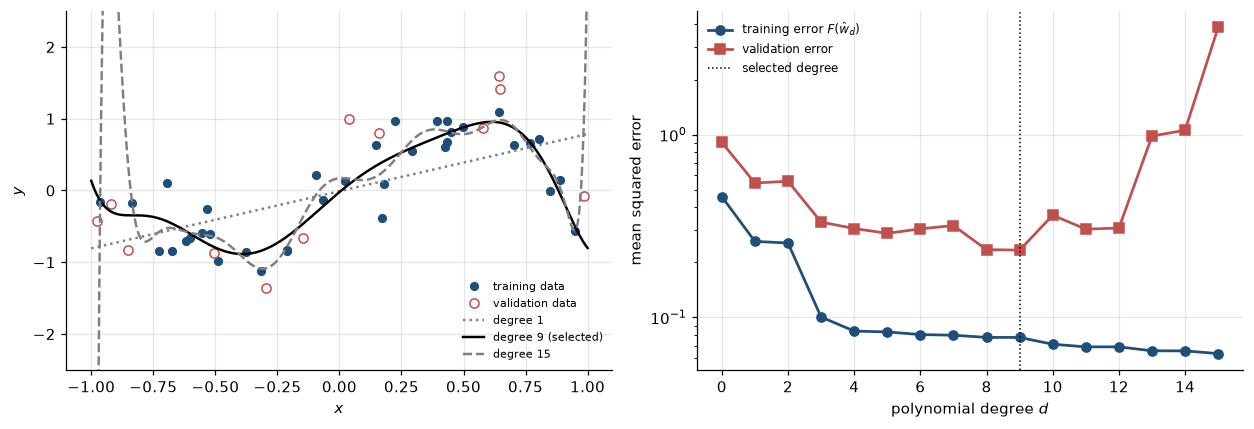

In [2]:
x9, y9 = regression_E9(rng)                                      # E9: 60 noisy samples
train_idx, val_idx, test_idx = split_indices(len(y9), rng)       # split BEFORE any fitting (36 / 12 / 12)
x_tr, y_tr, x_val, y_val = x9[train_idx], y9[train_idx], x9[val_idx], y9[val_idx]
degrees = np.arange(16)


def fit_polynomial(x, y, degree):
    # least-squares fit on the given data: minimizes the empirical squared loss
    return least_squares_fit(polynomial_features(x, degree), y)


def select_degree(x_tr, y_tr, x_val, y_val, degrees):
    # Fits every candidate on the TRAINING data and chooses the degree on the VALIDATION data.
    # There is deliberately no test argument.
    fits = [fit_polynomial(x_tr, y_tr, d) for d in degrees]
    train_err = np.array([mean_squared_error(polynomial_features(x_tr, d), w, y_tr) for d, w in zip(degrees, fits)])
    val_err = np.array([mean_squared_error(polynomial_features(x_val, d), w, y_val) for d, w in zip(degrees, fits)])
    return int(degrees[np.argmin(val_err)]), fits, train_err, val_err


selected_degree, fits, train_mse, val_mse = select_degree(x_tr, y_tr, x_val, y_val, degrees)
print("degree:         ", degrees)
print("training MSE:   ", np.round(train_mse, 3))
print("validation MSE: ", np.round(val_mse, 3))
print("degree selected on the validation set:", selected_degree)

grid = np.linspace(-1, 1, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax1.plot(x_tr, y_tr, "o", color=COLORS["state"], ms=5, label="training data")
ax1.plot(x_val, y_val, "o", mfc="none", color=COLORS["control"], ms=6, label="validation data")
for d, style in ((1, ":"), (selected_degree, "-"), (15, "--")):
    ax1.plot(grid, polynomial_features(grid, d) @ fits[d], style, color="black" if d == selected_degree else COLORS["reference"],
             lw=1.6, label=f"degree {d}" + (" (selected)" if d == selected_degree else ""))
ax1.set_ylim(-2.5, 2.5); ax1.set_xlabel("$x$"); ax1.set_ylabel("$y$"); ax1.legend(fontsize=7, loc="lower right")
ax2.semilogy(degrees, train_mse, "o-", color=COLORS["state"], label="training error $F(\\hat w_d)$")
ax2.semilogy(degrees, val_mse, "s-", color=COLORS["control"], label="validation error")
ax2.axvline(selected_degree, color="black", ls=":", lw=1, label="selected degree")
ax2.set_xlabel("polynomial degree $d$"); ax2.set_ylabel("mean squared error"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** E9 regression with least-squares polynomials. *Left:* the 36 training samples (filled) and the 12 validation samples (open), with the fits of degree 1, of the selected degree, and of degree 15. The test samples are not shown: they are not used before the final evaluation. The degree-15 curve leaves the vertical range near $x=\pm1$. *Right:* training and validation mean squared errors against the degree (logarithmic scale).

*Interpretation (answer to the prediction).* The training error decreases at every degree (the classes are nested); the validation error first decreases and then explodes. Degree 1 *underfits*, missing the shape of $f$; degree 15 *overfits*, bending towards noisy training points and oscillating between them. The validation minimum is at degree 9, the selected model. A small training error is no evidence of a good model: fitting is not learning.

In [3]:
# Evaluation after the degree has been selected (no decision depends on these numbers).
w_selected = fits[selected_degree]
x_test, y_test = x9[test_idx], y9[test_idx]
test_mse_dev = mean_squared_error(polynomial_features(x_test, selected_degree), w_selected, y_test)   # development data
holdout_rng = rng.spawn(1)[0]               # the first (and only) child stream: independent of every draw of rng
x_new, y_new = regression_E9(holdout_rng, n=200)                     # fresh holdout, pre-specified (see the disclosure)
holdout_mse_selected = mean_squared_error(polynomial_features(x_new, selected_degree), w_selected, y_new)

protocol = {"train indices": train_idx, "validation indices": val_idx, "test indices": test_idx,
            "selected degree": selected_degree, "test MSE (development data)": test_mse_dev,
            "fresh holdout": "regression_E9(rng.spawn(1)[0], n=200)", "holdout MSE": holdout_mse_selected}
print(f"selected degree {selected_degree}: training MSE {train_mse[selected_degree]:.3f}, validation MSE {val_mse[selected_degree]:.3f}")
print(f"  12-sample test split (development data, exposed during design): MSE {test_mse_dev:.3f}")
print(f"  fresh holdout of 200 samples (pre-specified, single evaluation):  MSE {holdout_mse_selected:.3f}")
print("index sets disjoint:", not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx) or set(val_idx) & set(test_idx)))

selected degree 9: training MSE 0.078, validation MSE 0.233
  12-sample test split (development data, exposed during design): MSE 0.102
  fresh holdout of 200 samples (pre-specified, single evaluation):  MSE 0.112
index sets disjoint: True


## 4. Overfitting and the generalization gap
`CORE`

The laboratory shows the two failures of every learning problem. **Underfitting:** the class cannot represent the structure of the data, and training and validation errors are both large. **Overfitting:** the class is rich enough to fit the noise of the training sample, so the training error is small and the error on new data large.

**The training error always improves with complexity.** If $\mathcal H_d\subset\mathcal H_{d+1}$, as for polynomials of increasing degree, then $\min_{\mathcal H_{d+1}}F\le\min_{\mathcal H_d}F$: a minimum over more candidates cannot be larger. A monotone quantity cannot tell when to stop; the population risk is not monotone. §5 shows that the training error of a fitted model is moreover *systematically* optimistic.

> **Remark on the source slides.** P. 273 states that "SGD is less prone to overfitting because the data are chosen randomly". This is a heuristic, not a theorem: overfitting appears here with an exact solver (see notebook 10).

## 5. Selection bias: why the training error is optimistic
`CORE`

Let $S=\{(x_i,y_i)\}_{i=1}^N$ be a sample of $N$ independent draws from $\rho$, and write $F_S$ for the empirical risk computed on $S$.

> **Proposition 1 (unbiasedness for a fixed model).**
> *Assumptions:* the parameter $w$ is fixed, and does not depend on $S$; $\mathcal R(w)<\infty$.
> *Conclusion:* $\mathbb E_S\,F_S(w)=\mathcal R(w)$.
> *Interpretation:* for a model chosen *before* seeing the data, the average loss on the data is an honest estimate of the risk.

*Proof.* By linearity of expectation, $\mathbb E_S F_S(w)=\frac1N\sum_i\mathbb E\,\ell(\hat y(x_i;w),y_i)=\frac1N\sum_i\mathcal R(w)=\mathcal R(w)$, since each $(x_i,y_i)$ has law $\rho$ and $w$ does not depend on it. $\square$

**What goes wrong for a fitted model.** The estimate $\hat w(S)$ *depends on the sample*, while the proof used that $w$ is the same for every draw of $S$; so $\hat w(S)$ cannot be substituted, and in general $\mathbb E_S F_S(\hat w(S))\ne\mathbb E_S\mathcal R(\hat w(S))$. The data have been used twice, to choose $\hat w$ and to judge it: **selection bias**. Its sign depends on how $\hat w$ is chosen. For empirical risk minimization it is optimistic:

> **Proposition 2 (optimism of empirical risk minimization).**
> *Assumptions:* $\hat w(S)$ minimizes $F_S$ over a class $\mathcal H$ for every sample $S$; the population risk has a minimizer $w_{\mathcal H}$ over $\mathcal H$; the expectations are finite.
> *Conclusion:*
> $$\mathbb E_S\,F_S\big(\hat w(S)\big)\;\le\;\mathcal R(w_{\mathcal H})\;\le\;\mathbb E_S\,\mathcal R\big(\hat w(S)\big).$$
> *Interpretation:* on average, the fitted model's training error lies below the best risk in the class, and its risk above it.

*Proof.* For every sample, $F_S(\hat w(S))\le F_S(w_{\mathcal H})$, because $\hat w(S)$ minimizes $F_S$. Taking expectations and applying Proposition 1 to the fixed parameter $w_{\mathcal H}$ gives the first inequality. For every sample, $\mathcal R(w_{\mathcal H})\le\mathcal R(\hat w(S))$, because $w_{\mathcal H}$ minimizes $\mathcal R$ over $\mathcal H$; taking expectations gives the second. $\square$

Without such hypotheses no sign can be claimed (Exercise 3 builds a fitting rule with a pessimistic training error). *(Propositions 1–2 are a pedagogical addition.)*

**Laboratory.** E9 is synthetic, so its population risk can be computed by quadrature, an oracle no real application has. We draw 300 training samples of size 36, fit every degree on each, and average.

degree:                      [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
average training error:      [0.608 0.303 0.29  0.121 0.112 0.106 0.091 0.085 0.068 0.065 0.061 0.059
 0.056]
best risk in the class:      [0.635 0.331 0.331 0.139 0.131 0.127 0.117 0.117 0.095 0.095 0.09  0.09
 0.09 ]
average risk of the fit:     [  0.657   0.352   0.373   0.161   0.159   0.175   0.193   0.622   0.643
   1.73   14.265  32.337 221.763]
Proposition 2 holds for every degree: True


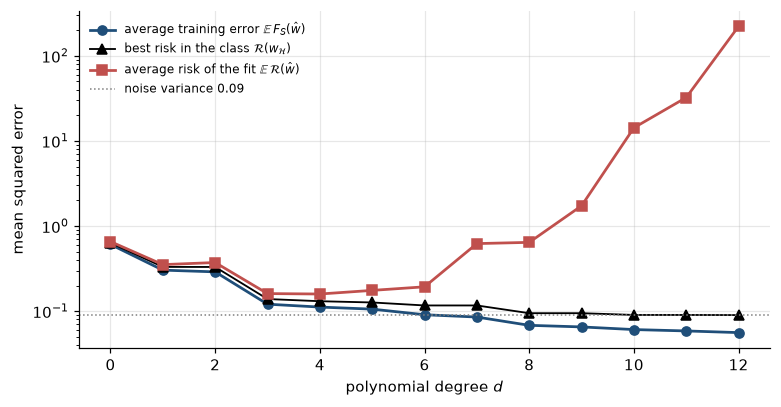

In [4]:
n_rep, degrees_sb = 300, np.arange(13)
nodes, weights = np.polynomial.legendre.leggauss(200)          # quadrature for the oracle E9 risk
best_in_class = np.empty(len(degrees_sb))
for d in degrees_sb:
    # w_H: least-squares projection of the target in L^2 of the uniform law on [-1, 1]
    root_w = np.sqrt(weights)
    w_H = least_squares_fit(root_w[:, None] * polynomial_features(nodes, d), root_w * target_E9(nodes))
    best_in_class[d] = population_risk_E9(lambda t: polynomial_features(t, d) @ w_H)

train_err_rep = np.empty((n_rep, len(degrees_sb)))
risk_rep = np.empty((n_rep, len(degrees_sb)))
for r in range(n_rep):
    xs, ys = regression_E9(rng, n=36)                           # a fresh training sample of the same size
    for d in degrees_sb:
        w_hat = fit_polynomial(xs, ys, d)
        train_err_rep[r, d] = mean_squared_error(polynomial_features(xs, d), w_hat, ys)
        risk_rep[r, d] = population_risk_E9(lambda t: polynomial_features(t, d) @ w_hat)
avg_train, avg_risk = train_err_rep.mean(axis=0), risk_rep.mean(axis=0)
print("degree:                     ", degrees_sb)
print("average training error:     ", np.round(avg_train, 3))
print("best risk in the class:     ", np.round(best_in_class, 3))
print("average risk of the fit:    ", np.round(avg_risk, 3))
print("Proposition 2 holds for every degree:", bool(np.all(avg_train <= best_in_class) and np.all(best_in_class <= avg_risk)))

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.semilogy(degrees_sb, avg_train, "o-", color=COLORS["state"], label=r"average training error $\mathbb{E}\,F_S(\hat w)$")
ax.semilogy(degrees_sb, best_in_class, "^-", color="black", lw=1.2, label=r"best risk in the class $\mathcal{R}(w_{\mathcal{H}})$")
ax.semilogy(degrees_sb, avg_risk, "s-", color=COLORS["control"], label=r"average risk of the fit $\mathbb{E}\,\mathcal{R}(\hat w)$")
ax.axhline(0.09, color=COLORS["reference"], ls=":", lw=1, label="noise variance $0.09$")
ax.set_xlabel("polynomial degree $d$"); ax.set_ylabel("mean squared error"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 2.** Averages over 300 independent training samples of size 36 from E9, for polynomial degrees $0,\dots,12$: the training error of the least-squares fit, the best risk achievable in the class (computed by quadrature), and the risk of the fit (computed by quadrature). The dotted line is the noise variance $0.3^2$, the smallest risk any predictor can have.

*Interpretation.* The curves are ordered as Proposition 2 says, at every degree. For large degrees the training error falls *below the noise variance*, which no predictor's risk can do: pure optimism. The average gap widens with the degree; richer classes contain better predictors, but with 36 samples the fit cannot find them, and its risk turns upward.

## 6. Training, validation and test sets
`CORE`

One level up, **the validation error of the selected model is also optimistic.** Given the training data, each candidate's validation error is unbiased for its risk (Proposition 1), but the selected candidate has the *smallest* one, and the expected minimum of unbiased estimates is at most the smallest of their expectations.

The **test set** repairs this. It is independent of the training and validation samples and plays no role in any choice, so for the test samples the selected model is a *fixed* model, and by Proposition 1 **the test error is an unbiased estimate of the risk of the selected model.** What matters is not how often the test set is evaluated but that **no decision depends on it**. As soon as a test result influences a choice (another degree, step size or stopping time, or even the design of the experiment), it has become a second validation set and its error is biased again.

| Set | Used to | Must not be used to |
|---|---|---|
| training | fit the parameters $w$ | judge the fitted model |
| validation | choose hyperparameters: degree, step size, stopping time, … | report final performance |
| test | report the performance, at the end | make any choice: no decision may depend on it |

**Protocol for notebooks 09–16** *(a pedagogical addition; the slides mention only the validation set, for early stopping, p. 273)*: (1) split once, before any fitting, and record the index sets; (2) fit every candidate on the training set; (3) select on the validation set and record the selection; (4) evaluate the selected model once on the test set. We do **not** refit on training and validation data together; that variant must be decided in advance. The dictionary `protocol` records the index sets, the selected degree and the test evaluation.

**One realization, not an average.** In our split the validation error at the selected degree is *larger* than the test error: the optimism concerns averages, and with 12 validation samples one split's fluctuation dominates it (Exercise 5).

## 7. A minimal neural network
`CORE`

The model behind most of the slides is a **feed-forward neural network**: a composition of affine maps and a fixed scalar nonlinearity $\sigma$ (the *activation*, e.g. $\tanh$ or $\max(0,\cdot)$), applied coordinate-wise. The slides write $\mathrm{NN}(x_i)$ inside the loss (p. 253) and use one hidden layer (pp. 327, 342). With width $P$ *(the explicit definition is a pedagogical addition)*:
$$
\hat y(x;w)=\sum_{j=1}^Pc_j\,\sigma(a_j\cdot x+b_j),\qquad w=(a_1,b_1,c_1,\dots,a_P,b_P,c_P)\in\mathbb R^{P(d+2)} .
$$
Each term is a **neuron** (inner weights $a_j$, bias $b_j$, outer weight $c_j$); deeper networks compose such layers, and §§2–6 apply unchanged.

**Why the loss can be nonconvex (p. 257).** Relabelling the neurons does not change the function $\hat y(\cdot;w)$, so every permutation of a global minimizer is again a global minimizer. Symmetry alone proves nothing: a convex function can be symmetric. What proves nonconvexity is a failure of Jensen's inequality $F(\tfrac12(w+w'))\le\tfrac12F(w)+\tfrac12F(w')$. The cell below builds one: the labels are the outputs of a fixed two-neuron network, so that network and its relabelling both have loss $0$, while the midpoint of the two parameter vectors, where the two neurons coincide, has positive loss. This shows that the loss *can* be nonconvex; it is a counterexample, not a theorem about every architecture and dataset.

In [5]:
def one_hidden_layer(x, a, b, c):
    # yhat(x) = sum_j c_j tanh(a_j . x + b_j);  x: (M, d), a: (P, d), b and c: (P,)
    return np.tanh(x @ a.T + b) @ c


a_nn, b_nn, c_nn = np.array([[1.0, -0.5], [-0.8, 1.2]]), np.array([0.3, -0.2]), np.array([1.0, -0.7])   # two neurons
y_syn = one_hidden_layer(X6, a_nn, b_nn, c_nn)              # labels produced by this very network (inputs of E6)
loss = lambda a, b, c: np.mean((one_hidden_layer(X6, a, b, c) - y_syn) ** 2)
swap = np.array([1, 0])                                     # relabel the two neurons
loss_w = loss(a_nn, b_nn, c_nn)
loss_perm = loss(a_nn[swap], b_nn[swap], c_nn[swap])
loss_mid = loss((a_nn + a_nn[swap]) / 2, (b_nn + b_nn[swap]) / 2, (c_nn + c_nn[swap]) / 2)
print(f"loss at w: {loss_w:.1e};  at its relabelling: {loss_perm:.1e};  at the midpoint: {loss_mid:.4f}")
print("Jensen's inequality fails (midpoint above the average of the endpoints):", loss_mid > (loss_w + loss_perm) / 2)

loss at w: 0.0e+00;  at its relabelling: 0.0e+00;  at the midpoint: 1.3564
Jensen's inequality fails (midpoint above the average of the endpoints): True


## 8. Control ↔ ML
`CORE`

- **Feedback and reinforcement learning.** **MATHEMATICAL ANALOGY.** The slides call reinforcement learning "learning based on feedback" (p. 70), the word used for control laws that depend on the observed state (p. 13; notebooks 01, 05). A feedback law is *designed* from a model; a policy is *learned* from rewards. The structure is shared, the mathematics differs.
- **Robustness is not generalization** (a contrast): robustness of controllability (notebook 02) concerns one known system, generalization new samples from an unknown law.
- **Training is minimization.** **DIRECT CONNECTION.** Minimizing $F$ is a problem of notebook 06; notebook 10 exploits that $F$ is an average over many samples.
- **Fitting data by a control.** **FORWARD CONNECTION.** In [notebook 14](14_classification_as_simultaneous_control.ipynb), classification is a simultaneous control problem; steering the training points is fitting, and whether new points are classified correctly is generalization, judged with the protocol of §6.

## 9. Federated learning: when the data cannot be pooled
`DEEPER LOOK`

In federated learning the data stay with many parties, because sending them is too costly or too sensitive (pp. 72–73). Learning alone on local data is not a solution either: a local dataset may be too small, which leads to overfitting, or biased, not representative of the target distribution (p. 74). The generic protocol (p. 75) is iterative: *initialize a model; each party updates it on its local data; the parties share their updates; a server aggregates them and sends the result back*. Unlike distributed learning, the local data are typically **not i.i.d.** and imbalanced (p. 76).

The cell below implements the simplest instance, federated averaging, on the E9 training data split among three parties, with polynomials of degree 5 (a lower degree than in §3, so that local gradient descent converges in a few hundred steps). Each round, every party performs 10 gradient-descent steps on its own data, starting from the current global model, and the server averages the three results. We compare an *i.i.d.* split of the 36 samples with a *non-i.i.d.* split by the value of $x$, in which each party sees only one third of the interval. Scores are validation errors; the test set is not used.

pooled data (centralized least squares): validation MSE 0.288
i.i.d.      each party alone: validation MSE ['0.333', '1.79', '0.414'];  federated averaging: 0.287, |w_fed - w_central| = 0.186
non-i.i.d.  each party alone: validation MSE ['1.36e+07', '3e+04', '1.46e+06'];  federated averaging: 0.270, |w_fed - w_central| = 0.078


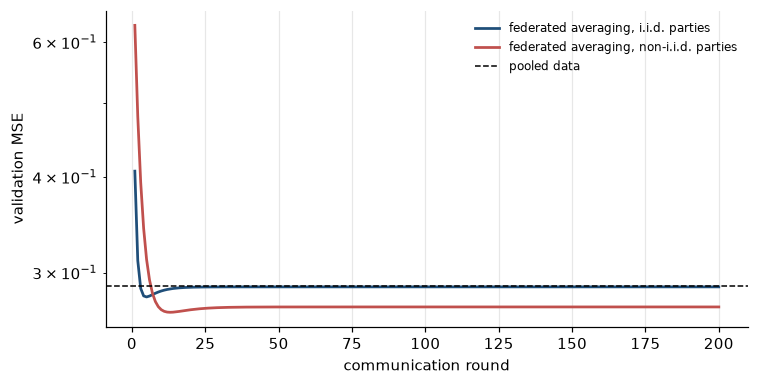

In [6]:
d_fed = 5
P_val_fed = polynomial_features(x_val, d_fed)
w_central = fit_polynomial(x_tr, y_tr, d_fed)                     # the model one would get by pooling the data
parties = {"i.i.d.": [np.arange(len(x_tr))[k::3] for k in range(3)],
           "non-i.i.d.": np.array_split(np.argsort(x_tr), 3)}     # by x: each party sees one third of [-1, 1]


def fedavg(groups, rounds=200, local_steps=10):
    w = np.zeros(d_fed + 1)
    history = []
    for _ in range(rounds):
        updates = []
        for g in groups:                                          # local gradient descent on each party's data
            A = polynomial_features(x_tr[g], d_fed)
            eta = 0.5 / np.linalg.eigvalsh(A.T @ A / len(g))[-1]
            v = w.copy()
            for _ in range(local_steps):
                v = v - eta * A.T @ (A @ v - y_tr[g]) / len(g)
            updates.append(v)
        w = np.mean(updates, axis=0)                              # the server averages (equal party sizes)
        history.append(mean_squared_error(P_val_fed, w, y_val))
    return w, np.array(history)


print(f"pooled data (centralized least squares): validation MSE {mean_squared_error(P_val_fed, w_central, y_val):.3f}")
fed_history = {}
for name, groups in parties.items():
    local = [fit_polynomial(x_tr[g], y_tr[g], d_fed) for g in groups]
    w_fed, fed_history[name] = fedavg(groups)
    print(f"{name:11s} each party alone: validation MSE {[f'{mean_squared_error(P_val_fed, w, y_val):.3g}' for w in local]};  "
          f"federated averaging: {fed_history[name][-1]:.3f}, |w_fed - w_central| = {np.linalg.norm(w_fed - w_central):.3f}")

fig, ax = plt.subplots(figsize=(7.0, 3.6))
for (name, hist), color in zip(fed_history.items(), (COLORS["state"], COLORS["control"])):
    ax.semilogy(np.arange(1, len(hist) + 1), hist, color=color, label=f"federated averaging, {name} parties")
ax.axhline(mean_squared_error(P_val_fed, w_central, y_val), color="black", ls="--", lw=1, label="pooled data")
ax.set_xlabel("communication round"); ax.set_ylabel("validation MSE"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** Federated averaging of degree-5 polynomials on the E9 training data split among three parties: validation error of the global model against the communication round, for an i.i.d. and a non-i.i.d. (split by $x$) assignment of the samples, compared with the model fitted on the pooled data.

*Interpretation.* With the non-i.i.d. split, each party alone produces a useless model: fitted on one third of the interval, it extrapolates wildly, as the printed validation errors show (p. 74, "the local dataset may be biased"). Federated averaging reaches, in a few rounds, a model whose validation error is close to that of the pooled data (for the non-i.i.d. split even slightly below it, a difference that 12 validation samples cannot resolve), without any party sharing its samples. Its limit is not exactly the pooled least-squares model (the printed distance is not zero): with several local steps per round, the parties drift towards their own minimizers, and averaging does not cancel this exactly. This *client drift* is one of the reasons why federated optimization is a research field of its own.

## 10. Common misconceptions
`CORE`

**"A small training error means a good model."** For empirical risk minimization under the hypotheses of Proposition 2, the training error is optimistic in expectation. For nested model classes fitted by exact minimization of the empirical risk, it cannot increase with complexity, whether or not the model generalizes (Figures 1–2). Neither statement applies automatically to every numerically trained model.

**"The training error estimates the risk, because it is an average over samples."** Only for a model chosen independently of those samples (Proposition 1).

**"The validation error of the selected model is the expected performance."** It is optimistic too (§6). For a predictor fixed independently of an i.i.d. evaluation sample, the mean loss on that sample is an unbiased estimate of the predictor's risk, if the loss is integrable. Neither the name "test" nor computing the number once creates this independence; reserving the test set until every decision is frozen is what preserves it.

**"Once a test set has been evaluated, it is spent."** What spoils a test set is a *decision* that depends on it, not the number of evaluations. Reporting several pre-specified procedures on it is compatible with the protocol; choosing among them by their test results turns it into a validation set.

## 11. What you should remember
`CORE`

1. Supervised learning: samples $(x_i,y_i)$ of an unknown law $\rho$; a hypothesis class $\hat y(\cdot;w)$; a loss $\ell$.
2. Empirical risk $F(w)=\frac1N\sum_i\ell(\hat y(x_i;w),y_i)$ is computed and minimized; population risk $\mathcal R(w)=\mathbb E\,\ell(\hat y(x;w),y)$ is what matters. $\mathcal R-F$ is the generalization gap.
3. Training error decreases with model complexity; the risk does not. Underfitting and overfitting are the two failures.
4. For a fixed model, $\mathbb E\,F_S(w)=\mathcal R(w)$. For a model fitted on $S$ this fails (selection bias); for empirical risk minimization the training error is optimistic on average.
5. Split once, before fitting: train to fit, validation to choose, test to report, with no decision depending on it. Record the indices and the choices.
6. A one-hidden-layer network is $\sum_jc_j\sigma(a_j\cdot x+b_j)$. Relabelling neurons gives other minimizers, and an explicit example (§7) shows that the loss can be nonconvex.

## 12. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (which paradigm?)** · `FIRST PASS`. Classify each task as supervised (regression or classification), unsupervised, reinforcement or federated learning, and say what the data contain: (a) predicting tomorrow's temperature from today's measurements; (b) grouping customers with similar purchase histories, without predefined groups; (c) a robot learning to walk from a reward for distance travelled; (d) recognizing handwritten digits from labelled images; (e) training a keyboard prediction model on millions of phones without uploading what users type; (f) learning a feedback law for the oscillator E1 from rewards, without knowing its equations.

**Exercise 2 ★★ (choosing on the test set)** · `FIRST PASS`. Suppose the degree in §3 had been chosen by minimizing the *test* error instead of the validation error. (a) Why is the reported test error then no longer an unbiased estimate of the risk of the chosen model? Use the argument of §6. (b) Is the chosen model necessarily worse? Is the *report* necessarily worse? (c) Describe a realistic way in which test information leaks into choices without anyone "fitting on the test set".

**Exercise 3 ★★ (the sign of the selection bias)** · `STANDARD`. (a) Prove Proposition 1 in detail, and point out where the independence of $w$ and $S$ is used. (b) Consider the absurd fitting rule $\hat w(S)=\arg\max_{w\in\mathcal H}F_S(w)$ over a finite class $\mathcal H$ containing at least two parameters with different risks. Show that $\mathbb E\,F_S(\hat w(S))\ge\max_{w\in\mathcal H}\mathcal R(w)\ge\mathbb E\,\mathcal R(\hat w(S))$: the training error is now *pessimistic*. (c) Conclude that the sign of the selection bias depends on the fitting rule, and identify the hypothesis of Proposition 2 that fails in (b).

**Exercise 4 ★★ (optimism of least squares, fixed design)** · `STANDARD`. Let $y=\Phi w_0+\varepsilon$ with a fixed design matrix $\Phi\in\mathbb R^{N\times D}$ of rank $D<N$, an unknown $w_0$, and noise $\varepsilon$ with independent components of mean $0$ and variance $s^2$. Let $\hat w$ be the least-squares estimate and $\Pi=\Phi(\Phi^\top\Phi)^{-1}\Phi^\top$. (a) Show that the training error is $\frac1N|(I-\Pi)\varepsilon|^2$ and that its expectation is $s^2(1-D/N)$. (b) For new responses $y'=\Phi w_0+\varepsilon'$ at the *same* inputs, with independent noise $\varepsilon'$, show that $\mathbb E\frac1N|y'-\Phi\hat w|^2=s^2(1+D/N)$. (c) Interpret the gap $2s^2D/N$, and compare with Figure 2.

**Exercise 5 ★★★ (k-fold cross-validation)** · `ADVANCED`. With 12 validation samples, the selection of §3 depends on one small split. Implement 6-fold cross-validation on the 48 training **and** validation samples together (the test samples stay untouched): split them into 6 folds, and for each degree average the validation errors obtained by fitting on 5 folds and validating on the sixth. Which degree is selected? Evaluate the cross-validated degree, refitted on all 48 samples, on the pre-specified fresh holdout `x_new, y_new` of §3 (do not generate another one), next to the §3 model's holdout error. Report both without choosing between them by their holdout results, and explain why that comparison is compatible with the protocol, and what would make it incompatible.

In [7]:
# TODO: student exercise (Exercise 5)
# Use only x9[train_idx], x9[val_idx] (and the matching y values) for cross-validation.
# Evaluate on the holdout arrays x_new, y_new of section 3; do not spawn a new generator.

def cross_validation_errors(x_cv, y_cv, degrees, n_folds):
    ...  # your code here
    return None

**Exercise 6 ★★★ (unsupervised learning: k-means on E6)** · `ADVANCED`. Ignore the labels of E6 and implement Lloyd's algorithm for $k=2$ clusters on the inputs `X6`: alternately assign each point to the nearest centre, and move each centre to the mean of its points. Start from the first two points of `X6` as centres, and stop when the assignment no longer changes. Compare the clusters with the true labels `y6`. Why can a method that minimizes a sensible clustering criterion disagree with the labels?

## Where are we going?
`CORE`

[Notebook 10](10_training_gd_sgd.ipynb) minimizes $F$ when it is an average over many samples (GD, SGD, mini-batches) and chooses *when to stop* on the validation set; [notebook 11](11_optimization_algorithms_ml.ipynb) adds memory and adaptivity.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Map | 49, 63–80, 85 | AI, ML, DL; unsupervised, supervised, reinforcement and federated learning; "optimization in ML is usually hard" |
| §2 Supervised problem | 69, 252–253, 255 | Samples of an unknown law; features, labels, model; classification and regression; parametrized model, loss, empirical loss |
| §4 Overfitting | 273 | "SGD is less prone to overfitting" (remark) |
| §6 Validation | 273 | Validation set for early stopping |
| §7 Network | 253, 257, 327, 342 | $\mathrm{NN}(x_i)$ in the loss; permutation symmetry and nonconvexity; one-hidden-layer form |
| §8 Control ↔ ML | 13, 70 | Feedback; RL as learning based on feedback |
| §9 Federated learning | 72–76 | Decentralized data; local data too small or biased; generic protocol; non-i.i.d. data |

The source-map rows also record the pedagogical additions: the definitions of $F$, $\mathcal R$ and the generalization gap, the E9 laboratory and Figure 1, the monotonicity of the training error, Propositions 1–2 (selection bias) and Figure 2, the train / validation / test protocol, the explicit network definition and its numerical check, and the federated-averaging laboratory and Figure 3. One remark on the source slides concerns p. 273.